In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
df = pd.read_csv("data/lamudi_apartemen_clean.csv")

print(df.shape)

df.head()

(1993, 11)


,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
0,DIJUAL CEPAT UNIT STUDIO TOWER MATOA LT. 17 WO...,600000000.0,"RW 07, Rawajati, Pancoran, Jakarta Selatan, Da...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,1.0,1.0,28.0,MoFu,https://www.lamudi.co.id/properti/41032-73-54c...
1,DI JUAL APARTEMEN 2 BEDROOM SKY HOUSE BSD – RE...,860000000.0,"BSD City, Pagedangan, Pagedangan, Kabupaten Ta...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-95c...
2,"Di jual 2BR Sky House BSD city, lokasi premium...",850000000.0,"BSD City, Pagedangan, Pagedangan, Kabupaten Ta...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-6b3...
3,INVESTASI TERBAIK 2026: 2BR SAMPING AEON BSD H...,840000000.0,"BSD Grand CBD, BSD City, Pagedangan, Pagedanga...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,48.0,Sky House BSD.,https://www.lamudi.co.id/properti/41032-73-246...
4,Dijual Apartemen Sepinggan Terrace Balikpapan,600000000.0,"Sepinggan Baru, Balikpapan Selatan, Balikpapan...",Balikpapan,Kalimantan Timur,Apartemen,2.0,1.0,29.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-f74...


In [3]:
df.nsmallest(20, "Harga")

,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
1151,Di Jual Croat Apt The Smith,2.0,"Alam Sutera, Pinang, Tangerang, Banten",Tangerang,Banten,Apartemen,1.0,1.0,60.0,Ratna Property,https://www.lamudi.co.id/properti/41032-73-8fb...
1636,APARTEMEN BASURA TOWER 1 Bergaya japannese Di ...,560.0,"RW 02, Cipinang Muara, Jatinegara, Jakarta Tim...",Jakarta Timur,Daerah Khusus Ibukota Jakarta,Apartemen,2.0,1.0,38.0,Era Fiesta,https://www.lamudi.co.id/properti/41032-73-d14...
11,Dijual apartemen U-Res 3 lokasi lippo karawaci...,600.0,"Lippo Village, Binong, Curug, Kabupaten Tanger...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,47.0,Linda Fang - Bossland Property,https://www.lamudi.co.id/properti/41032-73-358...
1183,termurah di kelasnya apartemen waterplace sela...,700000.0,"Pakuwon Indah, RW 06, Lidah Wetan, Lakarsantri...",Surabaya,Jawa Timur,Apartemen,3.0,2.0,85.0,indah wulan,https://www.lamudi.co.id/properti/41032-73-504...
240,Disewakan Apartemen Full Furnished Puncak Buki...,1200000.0,"RW 02, Wiyung, Wiyung, Surabaya, Jawa Timur",Surabaya,Jawa Timur,Apartemen,2.0,2.0,108.0,Irene - Be The Best Property,https://www.lamudi.co.id/properti/41032-73-717...
893,dijual cepat apartemen full furnish,1200000.0,"RW 09, Kebon Melati, Tanah Abang, Jakarta Pusa...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,2.0,1.0,56.0,Landmark,https://www.lamudi.co.id/properti/41032-73-d16...
361,SEWA APARTEMEN LAGOON RESOT BEKASI TIMUR FULL ...,3200000.0,"Kp Belter, Villa Taman Kartini, Rawasemut, Mar...",Bekasi,Jawa Barat,Apartemen,2.0,1.0,38.0,AMINUDIN,https://www.lamudi.co.id/jual/jawa-barat/bekas...
1268,SEWA APARTEMEN PREMIUM 2BR SKYHOUSE MURAHH | A...,9000000.0,"BSD City, Sampora, Cisauk, Kabupaten Tangerang...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Rinif Sky BSD,https://www.lamudi.co.id/properti/41032-73-abd...
1005,Apartemen Siap Huni dan Nyaman Modernland Tang...,13000000.0,"Kota Modern, Tangerang, Tangerang, Banten",Tangerang,Banten,Apartemen,2.0,1.0,34.0,Dream Home Property,https://www.lamudi.co.id/properti/41032-73-b31...
873,New Apartement in Sudirman Jakarta Selatan,63000000.0,"RW 04, Karet Semanggi, Setiabudi, Jakarta Sela...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,2.0,1.0,328.0,Linktown Expert - Michel,https://www.lamudi.co.id/properti/41032-73-936...


In [4]:
df.nlargest(20, "Harga")

,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
171,DIJUAL APARTEMEN SEDAYU CITY SUITE KELAPA GADI...,8.500000e+11,"RW 05, Rawa Terate, Cakung, Jakarta Timur, Dae...",Jakarta Timur,Daerah Khusus Ibukota Jakarta,Apartemen,1.0,1.0,28.0,Hanny (Agent Gading Pro),https://www.lamudi.co.id/jual/jakarta/jakarta-...
166,Apartemen WGP Dijual Murah Meriah,4.250000e+11,"RW 13, Kelapa Gading Timur, Kelapa Gading, Jak...",Jakarta Utara,Daerah Khusus Ibukota Jakarta,Apartemen,2.0,1.0,37.0,Tina - Ray White Prestige,https://www.lamudi.co.id/properti/41032-73-176...
1811,"JUAL RUMAH MEWAH JL.DIPONEGORO, MENTENG, JAKAR...",2.500000e+11,"RW 07, Menteng, Menteng, Jakarta Pusat, Daerah...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,5.0,5.0,1200.0,Kyu Properti,https://www.lamudi.co.id/properti/41032-73-ed5...
1751,amber park Singapore jual penthouse 6BR mewah ...,1.880000e+11,"Pakuwon City, RW 08, Kalisari, Mulyorejo, Sura...",Surabaya,Jawa Timur,Kondominium,7.0,5.0,408.0,Teni Property,https://www.lamudi.co.id/properti/41032-73-3ed...
1467,"DIJUAL GEDUNG KANTOR – JL. RAYA PASAR MINGGU, ...",7.500000e+10,"RW 02, Pancoran, Pancoran, Jakarta Selatan, Da...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,2.0,1.0,779.0,Ali Murtadha Alaydrus,https://www.lamudi.co.id/properti/41032-73-157...
314,"Dijual Cepat Royal Garden Apartement , di Da...",6.900000e+10,"Rangkapan Jaya, Pancoran Mas, Depok, Jawa Barat",Depok,Jawa Barat,Apartemen,2.0,1.0,6250.0,Buana Realty,https://www.lamudi.co.id/properti/41032-73-ebf...
307,Super Luxurious Semi Furnished Langham Residen...,5.000000e+10,"SCBD, Senayan, Kebayoran Baru, Jakarta Selatan...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,4.0,4.0,523.0,Casaterra Sedayu,https://www.lamudi.co.id/properti/41032-73-1cc...
157,Dijual Harga Menarik Gedung Perkantoran Areal ...,4.800000e+10,"RW 02, Cilandak Barat, Cilandak, Jakarta Selat...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Kondominium,2.0,1.0,47.0,David - Swift Pro,https://www.lamudi.co.id/properti/41032-73-711...
1813,Luxury Brand New Penthouse At The Regent Jakar...,3.900000e+10,"RW 04, Karet Semanggi, Setiabudi, Jakarta Sela...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,4.0,4.0,536.0,Nine Property,https://www.lamudi.co.id/properti/41032-73-d50...
296,Best price luxurious Apartemen The Langham Res...,3.500000e+10,"SCBD, Senayan, Kebayoran Baru, Jakarta Selatan...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,3.0,3.0,356.0,RE/MAX Premier JGC,https://www.lamudi.co.id/properti/41032-73-fb5...


In [5]:
df.sort_values("Kamar Tidur", ascending=False).head(20)

,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
72,Dijual Rumah Murah di Bekasi 2 Lantai FREE 2 TV,9.420000e+08,"Taman Rahayu, Kab Bekasi, Jawa Barat",Kab Bekasi,Jawa Barat,Apartemen,90.0,2.0,70.0,Tuvi Truvitas,https://www.lamudi.co.id/properti/41032-73-eee...
1639,Jual Rugi Aparment 1BR Brooklyn Alam Sutera,9.500000e+08,"Alam Sutera, Serpong Utara, Tangerang Selatan,...",Tangerang Selatan,Banten,Apartemen,45.0,1.0,45.0,Exis Prime Realty,https://www.lamudi.co.id/properti/41032-73-6d4...
1092,Bangunan Siap Huni 13 Mnt ke Terminal Lippo Ka...,1.658000e+10,"Cimone Jaya, Karawaci, Tangerang, Banten",Tangerang,Banten,Kondominium,40.0,41.0,2000.0,Pashouses,https://www.lamudi.co.id/properti/41032-73-17b...
1370,Rumah Kost Ring 1 UPN Yogyakarta Full Penghuni,9.000000e+09,"RW 02, Melawai, Kebayoran Baru, Jakarta Selata...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Kondominium,35.0,35.0,790.0,PT Risan Property Lancar,https://www.lamudi.co.id/properti/41032-73-a27...
1461,Kosan 30 kamar di A Rivai,6.630000e+09,"Bukit Kecil, Palembang, Sumatera Selatan",Palembang,Sumatera Selatan,Apartemen,30.0,30.0,654.0,M Faqih Fajri Imani Palembang,https://www.lamudi.co.id/properti/41032-73-17b...
1373,RUMAH KOST MEWAH NEMPEL KAMPUS UNDIP TEMBALANG...,2.800000e+10,"Tanah TNI AD, Sambiroto, Tembalang, Kota Semar...",Kota Semarang,Jawa Tengah,Kondominium,24.0,24.0,1500.0,PT Risan Property Lancar,https://www.lamudi.co.id/properti/41032-73-732...
804,Dijual Kost Elite di Nusa Dua Taman Mumbul,7.000000e+09,"Benoa, Kuta Selatan, Badung, Bali",Badung,Bali,Apartemen,21.0,21.0,750.0,Linktown Expert - Michel,https://www.lamudi.co.id/properti/41032-73-87b...
1926,"500 Meter UII, Kos Dijual Nglanjaran Jogja SHM",3.400000e+09,"Dero, Condongcatur, Depok, Sleman, Daerah Isti...",Sleman,Daerah Istimewa Yogyakarta,Apartemen,18.0,18.0,225.0,PT. Sekawan Makmur,https://www.lamudi.co.id/properti/41032-73-41f...
1367,RUMAH KOST DIJUAL FULL PENGHUNI SEMARANG BARAT...,4.500000e+09,"RW 03, Gisikdrono, Semarang Barat, Kota Semara...",Kota Semarang,Jawa Tengah,Kondominium,17.0,17.0,650.0,PT Risan Property Lancar,https://www.lamudi.co.id/properti/41032-73-88b...
1133,Rumah Dan Kost Aktif 3 Lantai Dekat UNS,1.900000e+09,"Gadingan, Sukoharjo, Jawa Tengah",Sukoharjo,Jawa Tengah,Apartemen,14.0,16.0,100.0,Hari Nugroho - Point Property Solo,https://www.lamudi.co.id/properti/41032-73-269...


In [6]:
df["Tipe Properti"].value_counts()

Tipe Properti
Apartemen             1932
Kondominium             58
Serviced Apartment       3
Name: count, dtype: int64

In [7]:
df.sort_values("Kamar Tidur", ascending=False)[
    ["Judul", "Tipe Properti", "Kamar Tidur", "Kamar Mandi", "Luas Total", "Harga", "Link"]
].head(10)

,Judul,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Harga,Link
72,Dijual Rumah Murah di Bekasi 2 Lantai FREE 2 TV,Apartemen,90.0,2.0,70.0,9.420000e+08,https://www.lamudi.co.id/properti/41032-73-eee...
1639,Jual Rugi Aparment 1BR Brooklyn Alam Sutera,Apartemen,45.0,1.0,45.0,9.500000e+08,https://www.lamudi.co.id/properti/41032-73-6d4...
1092,Bangunan Siap Huni 13 Mnt ke Terminal Lippo Ka...,Kondominium,40.0,41.0,2000.0,1.658000e+10,https://www.lamudi.co.id/properti/41032-73-17b...
1370,Rumah Kost Ring 1 UPN Yogyakarta Full Penghuni,Kondominium,35.0,35.0,790.0,9.000000e+09,https://www.lamudi.co.id/properti/41032-73-a27...
1461,Kosan 30 kamar di A Rivai,Apartemen,30.0,30.0,654.0,6.630000e+09,https://www.lamudi.co.id/properti/41032-73-17b...
1373,RUMAH KOST MEWAH NEMPEL KAMPUS UNDIP TEMBALANG...,Kondominium,24.0,24.0,1500.0,2.800000e+10,https://www.lamudi.co.id/properti/41032-73-732...
804,Dijual Kost Elite di Nusa Dua Taman Mumbul,Apartemen,21.0,21.0,750.0,7.000000e+09,https://www.lamudi.co.id/properti/41032-73-87b...
1926,"500 Meter UII, Kos Dijual Nglanjaran Jogja SHM",Apartemen,18.0,18.0,225.0,3.400000e+09,https://www.lamudi.co.id/properti/41032-73-41f...
1367,RUMAH KOST DIJUAL FULL PENGHUNI SEMARANG BARAT...,Kondominium,17.0,17.0,650.0,4.500000e+09,https://www.lamudi.co.id/properti/41032-73-88b...
1133,Rumah Dan Kost Aktif 3 Lantai Dekat UNS,Apartemen,14.0,16.0,100.0,1.900000e+09,https://www.lamudi.co.id/properti/41032-73-269...


In [8]:
df[df["Kamar Mandi"] >= 10][
    ["Judul", "Kamar Tidur", "Kamar Mandi", "Luas Total", "Harga"]
]

,Judul,Kamar Tidur,Kamar Mandi,Luas Total,Harga
804,Dijual Kost Elite di Nusa Dua Taman Mumbul,21.0,21.0,750.0,7.000000e+09
1092,Bangunan Siap Huni 13 Mnt ke Terminal Lippo Ka...,40.0,41.0,2000.0,1.658000e+10
1133,Rumah Dan Kost Aktif 3 Lantai Dekat UNS,14.0,16.0,100.0,1.900000e+09
1344,"Dijual apartemen Modern di Bintaro Jaya, siap ...",2.0,21.0,66.0,1.900000e+09
1367,RUMAH KOST DIJUAL FULL PENGHUNI SEMARANG BARAT...,17.0,17.0,650.0,4.500000e+09
1370,Rumah Kost Ring 1 UPN Yogyakarta Full Penghuni,35.0,35.0,790.0,9.000000e+09
1373,RUMAH KOST MEWAH NEMPEL KAMPUS UNDIP TEMBALANG...,24.0,24.0,1500.0,2.800000e+10
1461,Kosan 30 kamar di A Rivai,30.0,30.0,654.0,6.630000e+09
1699,Dijual Kost Exclusive Dekat Kampus UII Kaliurang,10.0,10.0,300.0,3.290000e+09
1755,Apartemen Roseville BSD,1.0,13.0,33.0,1.100000e+09


In [9]:
kata_hapus = [
    "rumah",
    "kost",
    "kos",
    "guest house",
    "guesthouse",
    "villa",
    "ruko",
    "hostel"
]

In [10]:
pattern = "|".join(kata_hapus)

df = df[
    ~df["Judul"].str.contains(
        pattern,
        case=False,
        na=False
    )
]

In [11]:
print(df.shape)

df["Judul"].head()

(1915, 11)


0    DIJUAL CEPAT UNIT STUDIO TOWER MATOA LT. 17 WO...
1    DI JUAL APARTEMEN 2 BEDROOM SKY HOUSE BSD – RE...
2    Di jual 2BR Sky House BSD city, lokasi premium...
3    INVESTASI TERBAIK 2026: 2BR SAMPING AEON BSD H...
4        Dijual Apartemen Sepinggan Terrace Balikpapan
Name: Judul, dtype: str

In [12]:
df.sort_values("Kamar Tidur", ascending=False).head(20)

,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
1639,Jual Rugi Aparment 1BR Brooklyn Alam Sutera,9.500000e+08,"Alam Sutera, Serpong Utara, Tangerang Selatan,...",Tangerang Selatan,Banten,Apartemen,45.0,1.0,45.0,Exis Prime Realty,https://www.lamudi.co.id/properti/41032-73-6d4...
1092,Bangunan Siap Huni 13 Mnt ke Terminal Lippo Ka...,1.658000e+10,"Cimone Jaya, Karawaci, Tangerang, Banten",Tangerang,Banten,Kondominium,40.0,41.0,2000.0,Pashouses,https://www.lamudi.co.id/properti/41032-73-17b...
1751,amber park Singapore jual penthouse 6BR mewah ...,1.880000e+11,"Pakuwon City, RW 08, Kalisari, Mulyorejo, Sura...",Surabaya,Jawa Timur,Kondominium,7.0,5.0,408.0,Teni Property,https://www.lamudi.co.id/properti/41032-73-3ed...
917,Dijual Apartemen Marigold Navapark BSD View Bo...,8.000000e+09,"Cibadak, Suradita, Cisauk, Kabupaten Tangerang...",Kabupaten Tangerang,Banten,Apartemen,6.0,5.0,202.0,Atlantis Realty Alam Sutera,https://www.lamudi.co.id/properti/41032-73-d3f...
1026,Dijual Apartemen Marigold Navapark BSD View Bo...,8.000000e+09,"Cibadak, Suradita, Cisauk, Kabupaten Tangerang...",Kabupaten Tangerang,Banten,Apartemen,6.0,5.0,202.0,Atlantis Realty - Lily Phiong,https://www.lamudi.co.id/properti/41032-73-b85...
1861,Apt St Moritz Ambasador,1.000000e+10,"RW 08, Kembangan Selatan, Kembangan, Jakarta B...",Jakarta Barat,Daerah Khusus Ibukota Jakarta,Apartemen,5.0,5.0,391.0,PropNex Kemang,https://www.lamudi.co.id/properti/41032-73-eb9...
1293,"Apartemen The Park Penthouse, Kelapa Gading, J...",6.000000e+09,"RW 21, Kelapa Gading Barat, Kelapa Gading, Jak...",Jakarta Utara,Daerah Khusus Ibukota Jakarta,Apartemen,5.0,3.0,320.0,Julius Ade Tjandrawidjaja - Ray White Kelapa G...,https://www.lamudi.co.id/properti/41032-73-b85...
1860,Apt St Moritz New Presidential,1.250000e+10,"RW 08, Kembangan Selatan, Kembangan, Jakarta B...",Jakarta Barat,Daerah Khusus Ibukota Jakarta,Apartemen,5.0,4.0,387.0,PropNex Kemang,https://www.lamudi.co.id/properti/41032-73-f24...
1203,Jual Rugi Apartemen Sherwood Residence / Penth...,7.500000e+09,"RW 06, Kelapa Gading Barat, Kelapa Gading, Jak...",Jakarta Utara,Daerah Khusus Ibukota Jakarta,Apartemen,5.0,4.0,278.0,Guruh Sohan - Independent Property Agent,https://www.lamudi.co.id/properti/41032-73-611...
1526,"For Sale THE RESIDENCES AT DHARMAWANGSA, Kebay...",3.200000e+10,"RW 02, Bangka, Mampang Prapatan, Jakarta Selat...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,5.0,4.0,453.0,Sari - Atlantis Realty Kelapa Gading,https://www.lamudi.co.id/jual/jakarta/jakarta-...


In [13]:
df[df["Kamar Tidur"] > 10][
    ["Judul", "Kamar Tidur", "Kamar Mandi", "Luas Total", "Harga", "Link"]
]

,Judul,Kamar Tidur,Kamar Mandi,Luas Total,Harga,Link
1092,Bangunan Siap Huni 13 Mnt ke Terminal Lippo Ka...,40.0,41.0,2000.0,1.658000e+10,https://www.lamudi.co.id/properti/41032-73-17b...
1639,Jual Rugi Aparment 1BR Brooklyn Alam Sutera,45.0,1.0,45.0,9.500000e+08,https://www.lamudi.co.id/properti/41032-73-6d4...


In [14]:
df.drop(index=[1092, 1639], inplace=True)

In [15]:
print(df.shape)

df[df["Kamar Tidur"] > 10]

(1913, 11)


,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link


In [16]:
df.describe()

,Harga,Kamar Tidur,Kamar Mandi,Luas Total
count,1.913000e+03,1913.000000,1913.000000,1913.000000
mean,2.791143e+09,1.888134,1.416623,83.730789
std,2.247752e+10,0.863019,0.884830,302.367910
min,2.000000e+00,1.000000,1.000000,3.000000
25%,4.900000e+08,1.000000,1.000000,33.000000
50%,9.000000e+08,2.000000,1.000000,47.000000
75%,1.950000e+09,2.000000,2.000000,81.000000
max,8.500000e+11,7.000000,21.000000,8741.000000


In [17]:
df[df["Kamar Mandi"] > 10][
    ["Judul", "Kamar Tidur", "Kamar Mandi", "Luas Total", "Harga", "Link"]
]

,Judul,Kamar Tidur,Kamar Mandi,Luas Total,Harga,Link
1344,"Dijual apartemen Modern di Bintaro Jaya, siap ...",2.0,21.0,66.0,1.900000e+09,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1755,Apartemen Roseville BSD,1.0,13.0,33.0,1.100000e+09,https://www.lamudi.co.id/jual/banten/tangerang...


In [18]:
df[df["Judul"].str.contains("Roseville", case=False, na=False)][
    ["Judul", "Kamar Tidur", "Kamar Mandi", "Luas Total", "Harga", "Link"]
]

,Judul,Kamar Tidur,Kamar Mandi,Luas Total,Harga,Link
125,Jual BU Apartemen Roseville SOHO & Suites 1BR ...,1.0,1.0,40.0,6.900000e+08,https://www.lamudi.co.id/properti/41032-73-fc1...
380,Jual Termurah Apartemen Roseville SOHO & Suite...,1.0,1.0,40.0,6.900000e+08,https://www.lamudi.co.id/properti/41032-73-9d3...
622,#0130 DIJUAL APARTEMEN ROSEVILLE SOHO & SUITES...,1.0,1.0,40.0,6.900000e+08,https://www.lamudi.co.id/properti/41032-73-f3c...
1755,Apartemen Roseville BSD,1.0,13.0,33.0,1.100000e+09,https://www.lamudi.co.id/jual/banten/tangerang...


In [19]:
df.drop(index=1755, inplace=True)

In [20]:
df.drop(index=1344, inplace=True)

In [21]:
df[df["Judul"].str.contains("Roseville", case=False, na=False)][
    ["Judul", "Kamar Tidur", "Kamar Mandi", "Luas Total", "Harga", "Link"]
]

,Judul,Kamar Tidur,Kamar Mandi,Luas Total,Harga,Link
125,Jual BU Apartemen Roseville SOHO & Suites 1BR ...,1.0,1.0,40.0,690000000.0,https://www.lamudi.co.id/properti/41032-73-fc1...
380,Jual Termurah Apartemen Roseville SOHO & Suite...,1.0,1.0,40.0,690000000.0,https://www.lamudi.co.id/properti/41032-73-9d3...
622,#0130 DIJUAL APARTEMEN ROSEVILLE SOHO & SUITES...,1.0,1.0,40.0,690000000.0,https://www.lamudi.co.id/properti/41032-73-f3c...


In [22]:
df.nsmallest(10, "Harga")[
    ["Judul", "Harga", "Luas Total", "Kamar Tidur", "Kamar Mandi", "Link"]
]

,Judul,Harga,Luas Total,Kamar Tidur,Kamar Mandi,Link
1151,Di Jual Croat Apt The Smith,2.0,60.0,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-8fb...
1636,APARTEMEN BASURA TOWER 1 Bergaya japannese Di ...,560.0,38.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-d14...
11,Dijual apartemen U-Res 3 lokasi lippo karawaci...,600.0,47.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-358...
1183,termurah di kelasnya apartemen waterplace sela...,700000.0,85.0,3.0,2.0,https://www.lamudi.co.id/properti/41032-73-504...
240,Disewakan Apartemen Full Furnished Puncak Buki...,1200000.0,108.0,2.0,2.0,https://www.lamudi.co.id/properti/41032-73-717...
893,dijual cepat apartemen full furnish,1200000.0,56.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-d16...
361,SEWA APARTEMEN LAGOON RESOT BEKASI TIMUR FULL ...,3200000.0,38.0,2.0,1.0,https://www.lamudi.co.id/jual/jawa-barat/bekas...
1268,SEWA APARTEMEN PREMIUM 2BR SKYHOUSE MURAHH | A...,9000000.0,51.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-abd...
1005,Apartemen Siap Huni dan Nyaman Modernland Tang...,13000000.0,34.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-b31...
873,New Apartement in Sudirman Jakarta Selatan,63000000.0,328.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-936...


In [23]:
df.drop(index=[1151, 1636, 11], inplace=True)

In [24]:
df.nsmallest(10, "Harga")[
    ["Judul", "Harga", "Luas Total", "Kamar Tidur", "Kamar Mandi", "Link"]
]

,Judul,Harga,Luas Total,Kamar Tidur,Kamar Mandi,Link
1183,termurah di kelasnya apartemen waterplace sela...,700000.0,85.0,3.0,2.0,https://www.lamudi.co.id/properti/41032-73-504...
240,Disewakan Apartemen Full Furnished Puncak Buki...,1200000.0,108.0,2.0,2.0,https://www.lamudi.co.id/properti/41032-73-717...
893,dijual cepat apartemen full furnish,1200000.0,56.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-d16...
361,SEWA APARTEMEN LAGOON RESOT BEKASI TIMUR FULL ...,3200000.0,38.0,2.0,1.0,https://www.lamudi.co.id/jual/jawa-barat/bekas...
1268,SEWA APARTEMEN PREMIUM 2BR SKYHOUSE MURAHH | A...,9000000.0,51.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-abd...
1005,Apartemen Siap Huni dan Nyaman Modernland Tang...,13000000.0,34.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-b31...
873,New Apartement in Sudirman Jakarta Selatan,63000000.0,328.0,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-936...
1610,Apartemen Puncak CBD Tower A Type Studio Siap ...,100000000.0,21.0,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-cd8...
103,Apartemen Aeropolis STUDIO Hunian Strategis D...,105000000.0,12.0,1.0,1.0,https://www.lamudi.co.id/jual/banten/tangerang...
117,TAKE OVER DP!!! JUAL APARTEMEN MURAH MAJAPAHIT...,115000000.0,22.0,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-96d...


In [25]:
df.nlargest(10, "Luas Total")[
    ["Judul", "Luas Total", "Harga", "Kamar Tidur", "Kamar Mandi", "Link"]
]

,Judul,Luas Total,Harga,Kamar Tidur,Kamar Mandi,Link
1670,Dijual Via Lelang Tanah dan Bangunan Jalan Ahm...,8741.0,6.900000e+09,3.0,2.0,https://www.lamudi.co.id/properti/41032-73-64f...
1550,"Apartemen Capitol Suites Studio, 2 & 3 Bedroom...",6750.0,2.970000e+09,2.0,1.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
314,"Dijual Cepat Royal Garden Apartement , di Da...",6250.0,6.900000e+10,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-ebf...
1065,"Dijual Cepat dan Rugi Apartement, Unit Studio ...",2041.0,4.500000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-3e4...
560,APARTEMEN DIJUAL DI SOLO DEKAT TRANSMART PABEL...,1969.0,2.800000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-5b0...
885,2077. Dijual Apartemen Siap Huni Pusat Kota Su...,904.0,1.350000e+09,2.0,2.0,https://www.lamudi.co.id/properti/41032-73-a43...
1467,"DIJUAL GEDUNG KANTOR – JL. RAYA PASAR MINGGU, ...",779.0,7.500000e+10,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-157...
1813,Luxury Brand New Penthouse At The Regent Jakar...,536.0,3.900000e+10,4.0,4.0,https://www.lamudi.co.id/properti/41032-73-d50...
307,Super Luxurious Semi Furnished Langham Residen...,523.0,5.000000e+10,4.0,4.0,https://www.lamudi.co.id/properti/41032-73-1cc...
288,Dijual Apartemen Puncak Bukit Golf,522.0,4.250000e+08,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-3e6...


In [26]:
df.nsmallest(10, "Luas Total")[
    ["Judul", "Luas Total", "Harga", "Kamar Tidur", "Kamar Mandi", "Link"]
]

,Judul,Luas Total,Harga,Kamar Tidur,Kamar Mandi,Link
1615,Di Jual Apartemen Murah Tipe Studio,3.0,3.650000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-e74...
1136,Dijual Apartment | Gading icon Tower C Rosewoo...,4.0,3.000000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-833...
471,Dijual 1 unit apartemen harga murah dari pasar...,6.0,2.500000e+08,2.0,1.0,https://www.lamudi.co.id/properti/41032-73-ea2...
1197,Dijual Apartement Pondok Indah Resindence,11.0,7.750000e+09,2.0,2.0,https://www.lamudi.co.id/properti/41032-73-165...
103,Apartemen Aeropolis STUDIO Hunian Strategis D...,12.0,1.050000e+08,1.0,1.0,https://www.lamudi.co.id/jual/banten/tangerang...
106,Apartemen Aeropolis STUDIO Hunian Strategis F...,12.0,1.250000e+08,1.0,1.0,https://www.lamudi.co.id/jual/banten/tangerang...
1904,Turun Harga! Apartemen Paskal Lodge Type Studi...,15.0,2.500000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-776...
167,"Apart Spring Lake Summarecon Bekasi, D20-01, t...",17.0,3.500000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-fc5...
1908,Apartemen Type Studio Dijual di Jogja Dekat Ka...,17.0,3.500000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-a0f...
1922,"Apartemen Dijual di Jogja Dekat Kampus UPN, ST...",17.0,3.800000e+08,1.0,1.0,https://www.lamudi.co.id/properti/41032-73-4f8...


In [28]:
print(df.shape)

df.head()

(1908, 11)


,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
0,DIJUAL CEPAT UNIT STUDIO TOWER MATOA LT. 17 WO...,600000000.0,"RW 07, Rawajati, Pancoran, Jakarta Selatan, Da...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,1.0,1.0,28.0,MoFu,https://www.lamudi.co.id/properti/41032-73-54c...
1,DI JUAL APARTEMEN 2 BEDROOM SKY HOUSE BSD – RE...,860000000.0,"BSD City, Pagedangan, Pagedangan, Kabupaten Ta...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-95c...
2,"Di jual 2BR Sky House BSD city, lokasi premium...",850000000.0,"BSD City, Pagedangan, Pagedangan, Kabupaten Ta...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-6b3...
3,INVESTASI TERBAIK 2026: 2BR SAMPING AEON BSD H...,840000000.0,"BSD Grand CBD, BSD City, Pagedangan, Pagedanga...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,48.0,Sky House BSD.,https://www.lamudi.co.id/properti/41032-73-246...
4,Dijual Apartemen Sepinggan Terrace Balikpapan,600000000.0,"Sepinggan Baru, Balikpapan Selatan, Balikpapan...",Balikpapan,Kalimantan Timur,Apartemen,2.0,1.0,29.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-f74...


In [29]:
df.to_csv(
    "data/lamudi_apartemen_clean2.csv",
    index=False,
    encoding="utf-8-sig"
)

In [80]:
df = pd.read_csv("data/lamudi_apartemen_clean2.csv")

print(df.shape)

df.head()

(1861, 11)


,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
0,DIJUAL CEPAT UNIT STUDIO TOWER MATOA LT. 17 WO...,600000000.0,"RW 07, Rawajati, Pancoran, Jakarta Selatan, Da...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,1.0,1.0,28.0,MoFu,https://www.lamudi.co.id/properti/41032-73-54c...
1,DI JUAL APARTEMEN 2 BEDROOM SKY HOUSE BSD – RE...,860000000.0,"BSD City, Pagedangan, Pagedangan, Kabupaten Ta...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-95c...
2,"Di jual 2BR Sky House BSD city, lokasi premium...",850000000.0,"BSD City, Pagedangan, Pagedangan, Kabupaten Ta...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,51.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-6b3...
3,INVESTASI TERBAIK 2026: 2BR SAMPING AEON BSD H...,840000000.0,"BSD Grand CBD, BSD City, Pagedangan, Pagedanga...",Kabupaten Tangerang,Banten,Apartemen,2.0,1.0,48.0,Sky House BSD.,https://www.lamudi.co.id/properti/41032-73-246...
4,Dijual Apartemen Sepinggan Terrace Balikpapan,600000000.0,"Sepinggan Baru, Balikpapan Selatan, Balikpapan...",Balikpapan,Kalimantan Timur,Apartemen,2.0,1.0,29.0,Frans Property,https://www.lamudi.co.id/properti/41032-73-f74...


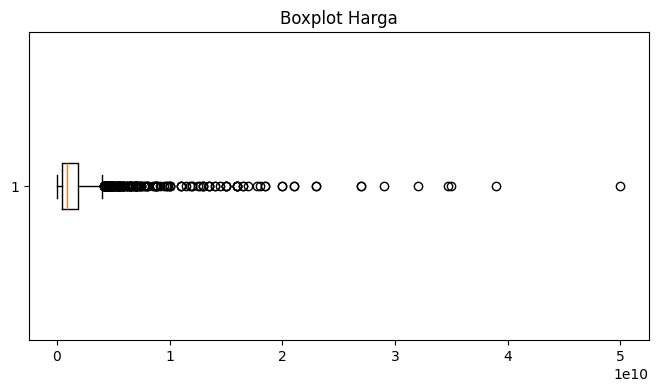

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.boxplot(df["Harga"], vert=False)

plt.title("Boxplot Harga")

plt.show()

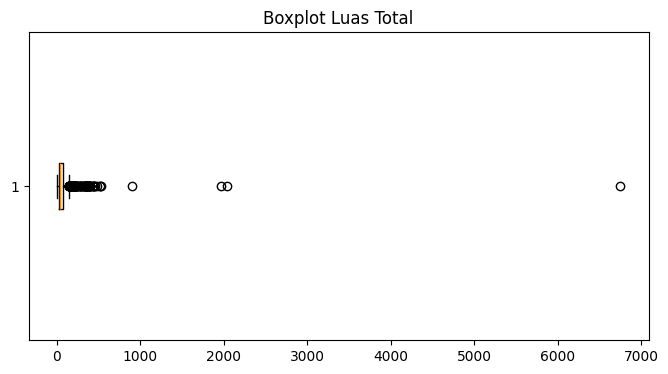

In [83]:
plt.figure(figsize=(8,4))

plt.boxplot(df["Luas Total"], vert=False)

plt.title("Boxplot Luas Total")

plt.show()

In [84]:
Q1 = df["Harga"].quantile(0.25)
Q3 = df["Harga"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-1637500000.0
4022500000.0


In [85]:
outlier_harga = df[
    (df["Harga"] < lower) |
    (df["Harga"] > upper)
]

print(outlier_harga.shape)

outlier_harga.head()

(178, 11)


,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
27,Apartemen dengan kolam renang pribadi di Ubud ...,4.800000e+09,"Tua, Luwus, Tabanan, Bali",Tabanan,Bali,Apartemen,1.0,1.0,96.0,DDA Real Estate,https://www.lamudi.co.id/properti/41032-73-803...
35,Apartemen Mewah 3 Kamar – Fully Furnished | Di...,8.500000e+09,"RW 09, Karet Tengsin, Tanah Abang, Jakarta Pus...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,3.0,3.0,148.0,Casa Domaine Residences,https://www.lamudi.co.id/properti/41032-73-834...
36,Luxury 4 Bedroom Apartment – Fully Furnished |...,2.000000e+10,"RW 05, Karet Tengsin, Tanah Abang, Jakarta Pus...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,4.0,4.0,296.0,Casa Domaine Residences,https://www.lamudi.co.id/properti/41032-73-935...
55,For sale apartment essence east tower dharmawa...,6.500000e+09,"RW 08, Cipete Utara, Kebayoran Baru, Jakarta S...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,3.0,3.0,180.0,Ali Murtadha Alaydrus,https://www.lamudi.co.id/properti/41032-73-a61...
71,Dijual Murah !!! Apartemen 31 Sudirman 3+1 Sig...,4.800000e+09,"Mangkura, Mangkura, Ujung Pandang, Makassar, S...",Makassar,Sulawesi Selatan,Apartemen,4.0,3.0,123.0,Duta Properti Makassar - nasrah,https://www.lamudi.co.id/jual/sulawesi-selatan...


In [86]:
Q1 = df["Luas Total"].quantile(0.25)
Q3 = df["Luas Total"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [87]:
outlier_luas = df[
    (df["Luas Total"] < lower) |
    (df["Luas Total"] > upper)
]

print(outlier_luas.shape)

outlier_luas.head()

(151, 11)


,Judul,Harga,Lokasi,Kota,Provinsi,Tipe Properti,Kamar Tidur,Kamar Mandi,Luas Total,Nama Agen,Link
36,Luxury 4 Bedroom Apartment – Fully Furnished |...,2.000000e+10,"RW 05, Karet Tengsin, Tanah Abang, Jakarta Pus...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,4.0,4.0,296.0,Casa Domaine Residences,https://www.lamudi.co.id/properti/41032-73-935...
55,For sale apartment essence east tower dharmawa...,6.500000e+09,"RW 08, Cipete Utara, Kebayoran Baru, Jakarta S...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,3.0,3.0,180.0,Ali Murtadha Alaydrus,https://www.lamudi.co.id/properti/41032-73-a61...
89,3 Bedroom Anandamaya Residence Tower 1 - semi...,2.300000e+10,"RW 05, Karet Tengsin, Tanah Abang, Jakarta Pus...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,3.0,3.0,267.0,Tantea Hestiwening,https://www.lamudi.co.id/jual/jakarta/jakarta-...
105,Dijual 4 Bedroom District 8 Infinity Tower – J...,1.600000e+10,"RW 01, Senayan, Kebayoran Baru, Jakarta Selata...",Jakarta Selatan,Daerah Khusus Ibukota Jakarta,Apartemen,4.0,3.0,228.0,Tantea Hestiwening,https://www.lamudi.co.id/jual/jakarta/jakarta-...
119,Pakubuwono Menteng FOR SALE Fully Furnished,1.850000e+10,"RW 03, Kebon Sirih, Menteng, Jakarta Pusat, Da...",Jakarta Pusat,Daerah Khusus Ibukota Jakarta,Apartemen,3.0,3.0,210.0,Anastasia Soeprajogi - Pakubuwono Development,https://www.lamudi.co.id/properti/41032-73-86b...


In [88]:
df.nlargest(20, "Harga")[
    ["Judul", "Harga", "Luas Total", "Kota", "Link"]
]

,Judul,Harga,Luas Total,Kota,Link
283,Super Luxurious Semi Furnished Langham Residen...,5.000000e+10,523.0,Jakarta Selatan,https://www.lamudi.co.id/properti/41032-73-1cc...
1687,Luxury Brand New Penthouse At The Regent Jakar...,3.900000e+10,536.0,Jakarta Selatan,https://www.lamudi.co.id/properti/41032-73-d50...
272,Best price luxurious Apartemen The Langham Res...,3.500000e+10,356.0,Jakarta Selatan,https://www.lamudi.co.id/properti/41032-73-fb5...
1300,Leasehold - Oceanfront Penthouse di Canggu Roo...,3.470000e+10,400.0,Badung,https://www.lamudi.co.id/jual/bali/badung/leas...
1425,"For Sale THE RESIDENCES AT DHARMAWANGSA, Kebay...",3.200000e+10,453.0,Jakarta Selatan,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1041,Dijual Apartemen Dharmanwangsa jakarta selatan,2.900000e+10,453.0,Jakarta Selatan,https://www.lamudi.co.id/properti/41032-73-a77...
311,Apartemen mewah Raffles Residence 4BR Kuningan,2.700000e+10,480.0,Jakarta Selatan,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1268,DHARMAWANGSA RESIDENCES 2,2.700000e+10,462.0,Jakarta Selatan,https://www.lamudi.co.id/properti/41032-73-f8f...
89,3 Bedroom Anandamaya Residence Tower 1 - semi...,2.300000e+10,267.0,Jakarta Pusat,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1674,For Sale Apartment Anandamaya Residence 3 BR 2...,2.300000e+10,268.0,Jakarta Pusat,https://www.lamudi.co.id/properti/41032-73-9b6...


In [89]:
df.nlargest(20, "Luas Total")[
    ["Judul", "Luas Total", "Harga", "Kamar Tidur", "Link"]
]

,Judul,Luas Total,Harga,Kamar Tidur,Link
1448,"Apartemen Capitol Suites Studio, 2 & 3 Bedroom...",6750.0,2.970000e+09,2.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
992,"Dijual Cepat dan Rugi Apartement, Unit Studio ...",2041.0,4.500000e+08,1.0,https://www.lamudi.co.id/properti/41032-73-3e4...
518,APARTEMEN DIJUAL DI SOLO DEKAT TRANSMART PABEL...,1969.0,2.800000e+08,1.0,https://www.lamudi.co.id/properti/41032-73-5b0...
823,2077. Dijual Apartemen Siap Huni Pusat Kota Su...,904.0,1.350000e+09,2.0,https://www.lamudi.co.id/properti/41032-73-a43...
1687,Luxury Brand New Penthouse At The Regent Jakar...,536.0,3.900000e+10,4.0,https://www.lamudi.co.id/properti/41032-73-d50...
283,Super Luxurious Semi Furnished Langham Residen...,523.0,5.000000e+10,4.0,https://www.lamudi.co.id/properti/41032-73-1cc...
265,Dijual Apartemen Puncak Bukit Golf,522.0,4.250000e+08,2.0,https://www.lamudi.co.id/properti/41032-73-3e6...
311,Apartemen mewah Raffles Residence 4BR Kuningan,480.0,2.700000e+10,4.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1268,DHARMAWANGSA RESIDENCES 2,462.0,2.700000e+10,3.0,https://www.lamudi.co.id/properti/41032-73-f8f...
1041,Dijual Apartemen Dharmanwangsa jakarta selatan,453.0,2.900000e+10,3.0,https://www.lamudi.co.id/properti/41032-73-a77...


In [90]:
df = df[df["Tipe Properti"] == "Apartemen"].copy()

In [91]:
print(df["Tipe Properti"].value_counts())
print(df.shape)

Tipe Properti
Apartemen    1861
Name: count, dtype: int64
(1861, 11)


In [92]:
df.drop(
    index=[155, 150, 1371, 291],
    inplace=True
)

In [93]:
df.reset_index(drop=True, inplace=True)

In [94]:
keywords = [
    "gedung",
    "tower penuh",
    "hotel",
    "kost",
    "kos",
    "ruko",
    "rumah",
    "guest house",
    "building"
]

mask = df["Judul"].str.contains("|".join(keywords), case=False, na=False)

df[mask][["Judul", "Harga", "Luas Total", "Link"]]

,Judul,Harga,Luas Total,Link
53,"HOOOK ,Samping lift Dijual Apartemen STA Sentu...",3.000000e+08,23.0,https://www.lamudi.co.id/properti/41032-73-198...
720,Jual Apartement Tree Park City Tower Alphine L...,1.100000e+09,53.0,https://www.lamudi.co.id/properti/41032-73-9ac...
932,Best View Apart Parkland Avenue di Hotel Sahid...,6.500000e+08,36.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1165,Apart-hotel hanya 200 meter dari laut dan spot...,1.430000e+09,31.0,https://www.lamudi.co.id/properti/41032-73-611...


In [95]:
df.nlargest(20, "Harga")[
    ["Judul", "Harga", "Luas Total", "Kamar Tidur", "Kamar Mandi", "Link"]
]

,Judul,Harga,Luas Total,Kamar Tidur,Kamar Mandi,Link
281,Super Luxurious Semi Furnished Langham Residen...,5.000000e+10,523.0,4.0,4.0,https://www.lamudi.co.id/properti/41032-73-1cc...
1683,Luxury Brand New Penthouse At The Regent Jakar...,3.900000e+10,536.0,4.0,4.0,https://www.lamudi.co.id/properti/41032-73-d50...
270,Best price luxurious Apartemen The Langham Res...,3.500000e+10,356.0,3.0,3.0,https://www.lamudi.co.id/properti/41032-73-fb5...
1297,Leasehold - Oceanfront Penthouse di Canggu Roo...,3.470000e+10,400.0,3.0,3.0,https://www.lamudi.co.id/jual/bali/badung/leas...
1421,"For Sale THE RESIDENCES AT DHARMAWANGSA, Kebay...",3.200000e+10,453.0,5.0,4.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1038,Dijual Apartemen Dharmanwangsa jakarta selatan,2.900000e+10,453.0,3.0,3.0,https://www.lamudi.co.id/properti/41032-73-a77...
308,Apartemen mewah Raffles Residence 4BR Kuningan,2.700000e+10,480.0,4.0,4.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1265,DHARMAWANGSA RESIDENCES 2,2.700000e+10,462.0,3.0,3.0,https://www.lamudi.co.id/properti/41032-73-f8f...
89,3 Bedroom Anandamaya Residence Tower 1 - semi...,2.300000e+10,267.0,3.0,3.0,https://www.lamudi.co.id/jual/jakarta/jakarta-...
1670,For Sale Apartment Anandamaya Residence 3 BR 2...,2.300000e+10,268.0,3.0,3.0,https://www.lamudi.co.id/properti/41032-73-9b6...


In [106]:
df[df["Luas Total"] > 1000][
    ["Judul", "Luas Total", "Harga", "Link"]
].sort_values("Luas Total", ascending=False)

,Judul,Luas Total,Harga,Link


In [105]:
df.drop(
    index=[989],
    inplace=True
)

In [107]:
df.reset_index(drop=True, inplace=True)

df.to_csv(
    "data/lamudi_apartemen_clean_final.csv",
    index=False,
    encoding="utf-8-sig"
)